Step 2 — Preprocess & Split

In [2]:
# Step 2 — Preprocess & Split
import os, random, numpy as np
import tensorflow as tf
import cv2
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, precision_recall_fscore_support,
                             cohen_kappa_score, roc_auc_score)
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import Xception
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# Mount Google Drive
drive.mount('/content/drive')

# Paths
dataset_root = '/content/drive/MyDrive/PlantDoc-Dataset'
train_dir = f'{dataset_root}/train'
test_dir  = f'{dataset_root}/test'

# Loader
def load_plantdoc_data(data_dir, img_size=(299, 299)):
    X, y = [], []
    class_names = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
    class_to_idx = {cls_name: idx for idx, cls_name in enumerate(class_names)}
    for cls_name in class_names:
        cls_dir = os.path.join(data_dir, cls_name)
        for img_name in os.listdir(cls_dir):
            img_path = os.path.join(cls_dir, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, img_size)
            X.append(img)
            y.append(class_to_idx[cls_name])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32), class_names

# Load train/test
X_train, y_train, class_names = load_plantdoc_data(train_dir)
X_test,  y_test,  _           = load_plantdoc_data(test_dir)
num_classes = len(class_names)

# Normalize
X_train = X_train / 255.0
X_test  = X_test  / 255.0

# Split train → 80% train + 20% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=SEED
)

# One-hot encode
y_train_cat = to_categorical(y_train, num_classes)
y_val_cat   = to_categorical(y_val, num_classes)
y_test_cat  = to_categorical(y_test, num_classes)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train: (1852, 299, 299, 3), Val: (464, 299, 299, 3), Test: (236, 299, 299, 3)


Step 3 — Class Weights (handle imbalance)

In [3]:
# Step 3 — Class Weights (handle imbalance)
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(num_classes),
    y=y_train
)
class_weights = {i: w for i, w in enumerate(class_weights)}
print("Class Weights:", class_weights)


Class Weights: {0: np.float64(1.1063321385902032), 1: np.float64(1.0392817059483725), 2: np.float64(1.0887713109935333), 3: np.float64(1.6331569664902998), 4: np.float64(1.3718518518518519), 5: np.float64(0.8165784832451499), 6: np.float64(1.8050682261208577), 7: np.float64(1.3449527959331882), 8: np.float64(0.4763374485596708), 9: np.float64(0.8069716775599128), 10: np.float64(0.8364950316169828), 11: np.float64(0.7884206045125586), 12: np.float64(0.879392212725546), 13: np.float64(0.7884206045125586), 14: np.float64(1.4911433172302737), 15: np.float64(0.6999244142101285), 16: np.float64(0.9798941798941799), 17: np.float64(1.162586315128688), 18: np.float64(0.6292898402990146), 19: np.float64(1.595176571920758), 20: np.float64(0.879392212725546), 21: np.float64(0.846822130772748), 22: np.float64(1.9597883597883599), 23: np.float64(1.247138047138047), 24: np.float64(1.008714596949891), 25: np.float64(1.4911433172302737), 26: np.float64(1.5242798353909466)}


Step 4 — Kappa Callback (validation Kappa each epoch)

In [4]:
# Step 4 — Kappa Callback
class KappaCallback(tf.keras.callbacks.Callback):
    def __init__(self, X_val, y_val_cat):
        super().__init__()
        self.X_val = X_val
        self.y_val_cat = y_val_cat

    def on_epoch_end(self, epoch, logs=None):
        y_val_pred = np.argmax(self.model.predict(self.X_val, verbose=0), axis=1)
        y_val_true = np.argmax(self.y_val_cat, axis=1)
        kappa = cohen_kappa_score(y_val_true, y_val_pred)
        print(f"\nEpoch {epoch+1} — Val Cohen’s Kappa: {kappa:.4f}")


Step 5 — Build Model (with augmentation)

In [5]:
# Step 5 — Build Model (with augmentation)
def build_xception(num_classes, input_shape=(299, 299, 3), dropout=0.4, lr=1e-3,
                   label_smoothing=0.05, trainable_layers=0):

    aug = tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1),
    ], name="augment")

    base = Xception(include_top=False, weights='imagenet', input_shape=input_shape)

    # Freeze all layers
    for layer in base.layers:
        layer.trainable = False

    # Unfreeze last N layers if specified
    if trainable_layers > 0:
        for layer in base.layers[-trainable_layers:]:
            layer.trainable = True

    inputs = layers.Input(shape=input_shape)
    x = aug(inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)

    loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=label_smoothing)
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss=loss,
        metrics=['accuracy',
                 tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc'),
                 tf.keras.metrics.AUC(name='auc', multi_label=True)]
    )
    return model


Step 6 — Warmup (train head, base frozen)

In [6]:
# Step 6 — Warmup (train head, base frozen)
warmup_epochs = 3
model = build_xception(num_classes=num_classes, lr=1e-3, dropout=0.4,
                       label_smoothing=0.05, trainable_layers=0)
model.summary()

chkpt_path = "/content/best_warmup.keras"
callbacks_warmup = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.3, min_lr=1e-7),
    ModelCheckpoint(chkpt_path, monitor='val_loss', save_best_only=True, verbose=1),
    KappaCallback(X_val, y_val_cat)
]

history_warmup = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=warmup_epochs,
    batch_size=32,
    class_weight=class_weights,
    callbacks=callbacks_warmup,
    verbose=1
)


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augment (Sequential)            │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 10, 10, 2048)   │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 27)             │        13,851 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,926,467 (83.64 MB)

 Trainable params: 1,063,963 (4.06 MB)

 Non-trainable params: 20,862,504 (79.58 MB)

Epoch 1/3
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.1618 - auc: 0.6898 - loss: 3.5224 - top3_acc: 0.3399 
Epoch 1: val_loss improved from inf to 2.32650, saving model to /content/best_warmup.keras

Epoch 1 — Val Cohen’s Kappa: 0.3211
58/58 ━━━━━━━━━━━━━━━━━━━━ 1186s 20s/step - accuracy: 0.1629 - auc: 0.6912 - loss: 3.5157 - top3_acc: 0.3419 - val_accuracy: 0.3491 - val_auc: 0.9003 - val_loss: 2.3265 - val_top3_acc: 0.6530 - learning_rate: 0.0010
Epoch 2/3
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.4042 - auc: 0.8859 - loss: 2.2118 - top3_acc: 0.6807 
Epoch 2: val_loss improved from 2.32650 to 2.01550, saving model to /content/best_warmup.keras

Epoch 2 — Val Cohen’s Kappa: 0.4219
58/58 ━━━━━━━━━━━━━━━━━━━━ 1178s 20s/step - accuracy: 0.4041 - auc: 0.8860 - loss: 2.2127 - top3_acc: 0.6804 - val_accuracy: 0.4440 - val_auc: 0.9257 - val_loss: 2.0155 - val_top3_acc: 0.7328 - learning_rate: 0.0010
Epoch 3/3
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.4794 - auc:

Step 7 — Fine-tune (unfreeze last N layers, lower LR)

In [7]:
# Step 7 — Fine-tune (unfreeze last N layers, lower LR)
N_UNFREEZE = 60

# Find base model inside current model
base = None
for lyr in model.layers:
    if isinstance(lyr, tf.keras.Model) and lyr.name.startswith('xception'):
        base = lyr; break
if base is None:
    base = model.layers[2]  # fallback

# Freeze all, unfreeze last N layers
for l in base.layers:
    l.trainable = False
for l in base.layers[-N_UNFREEZE:]:
    l.trainable = True

# Recompile with lower LR
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy',
             tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc'),
             tf.keras.metrics.AUC(name='auc', multi_label=True)]
)

chkpt_path_ft = "/content/best_finetune.keras"
callbacks_ft = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.3, min_lr=1e-7),
    ModelCheckpoint(chkpt_path_ft, monitor='val_loss', save_best_only=True, verbose=1),
    KappaCallback(X_val, y_val_cat)
]

history_ft = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=20,
    batch_size=32,
    class_weight=class_weights,
    callbacks=callbacks_ft,
    verbose=1
)


Epoch 1/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 27s/step - accuracy: 0.4414 - auc: 0.9029 - loss: 2.0369 - top3_acc: 0.7019 
Epoch 1: val_loss improved from inf to 1.69516, saving model to /content/best_finetune.keras

Epoch 1 — Val Cohen’s Kappa: 0.5001
58/58 ━━━━━━━━━━━━━━━━━━━━ 1994s 34s/step - accuracy: 0.4418 - auc: 0.9033 - loss: 2.0355 - top3_acc: 0.7024 - val_accuracy: 0.5194 - val_auc: 0.9493 - val_loss: 1.6952 - val_top3_acc: 0.7909 - learning_rate: 1.0000e-04
Epoch 2/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 27s/step - accuracy: 0.6748 - auc: 0.9594 - loss: 1.3263 - top3_acc: 0.8869 
Epoch 2: val_loss improved from 1.69516 to 1.58282, saving model to /content/best_finetune.keras

Epoch 2 — Val Cohen’s Kappa: 0.5267
58/58 ━━━━━━━━━━━━━━━━━━━━ 1981s 34s/step - accuracy: 0.6743 - auc: 0.9596 - loss: 1.3272 - top3_acc: 0.8867 - val_accuracy: 0.5453 - val_auc: 0.9553 - val_loss: 1.5828 - val_top3_acc: 0.8211 - learning_rate: 1.0000e-04
Epoch 3/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 26s/step - accuracy

Step 8 — Evaluate (Accuracy, F1, AUC, Kappa, Report)

In [8]:
# Step 8 — Evaluate
y_pred_proba = model.predict(X_test, verbose=0)
y_pred = y_pred_proba.argmax(axis=1)
y_true = y_test

acc = accuracy_score(y_true, y_pred)
f1w = f1_score(y_true, y_pred, average='weighted')

try:
    macro_auc = roc_auc_score(y_test_cat, y_pred_proba, multi_class='ovr', average='macro')
except ValueError:
    macro_auc = np.nan

kappa = cohen_kappa_score(y_true, y_pred)
report = classification_report(y_true, y_pred, target_names=class_names)

print(f"Test Accuracy: {acc:.4f}")
print(f"Test Weighted F1: {f1w:.4f}")
print(f"Test Macro AUC (OvR): {macro_auc:.4f}")
print(f"Test Cohen's Kappa: {kappa:.4f}")
print("Classification Report:\n", report)


Test Accuracy: 0.5890
Test Weighted F1: 0.5953
Test Macro AUC (OvR): 0.9642
Test Cohen's Kappa: 0.5731
Classification Report:
                             precision    recall  f1-score   support

           Apple Scab Leaf       0.75      0.60      0.67        10
                Apple leaf       0.56      1.00      0.72         9
           Apple rust leaf       0.70      0.70      0.70        10
          Bell_pepper leaf       0.60      0.38      0.46         8
     Bell_pepper leaf spot       0.38      0.56      0.45         9
            Blueberry leaf       1.00      0.45      0.62        11
               Cherry leaf       0.64      0.70      0.67        10
       Corn Gray leaf spot       0.10      0.25      0.14         4
          Corn leaf blight       0.71      0.42      0.53        12
            Corn rust leaf       0.89      0.80      0.84        10
                Peach leaf       0.86      0.67      0.75         9
  Potato leaf early blight       0.36      0.62      0.4

Step 9 — Confusion Matrix & Per-class PRF

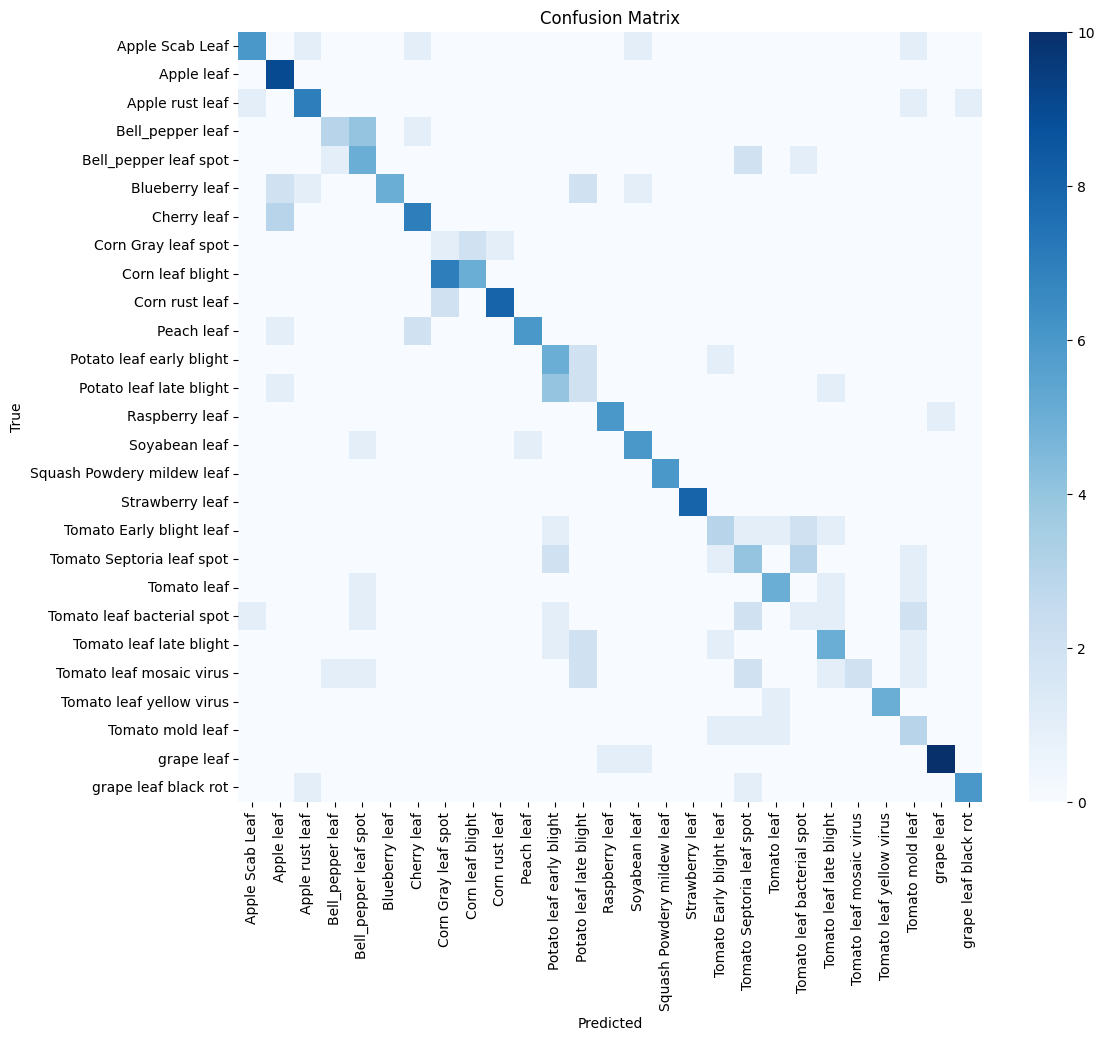

Apple Scab Leaf           | Precision: 0.750, Recall: 0.600, F1: 0.667, Support: 10
Apple leaf                | Precision: 0.562, Recall: 1.000, F1: 0.720, Support: 9
Apple rust leaf           | Precision: 0.700, Recall: 0.700, F1: 0.700, Support: 10
Bell_pepper leaf          | Precision: 0.600, Recall: 0.375, F1: 0.462, Support: 8
Bell_pepper leaf spot     | Precision: 0.385, Recall: 0.556, F1: 0.455, Support: 9
Blueberry leaf            | Precision: 1.000, Recall: 0.455, F1: 0.625, Support: 11
Cherry leaf               | Precision: 0.636, Recall: 0.700, F1: 0.667, Support: 10
Corn Gray leaf spot       | Precision: 0.100, Recall: 0.250, F1: 0.143, Support: 4
Corn leaf blight          | Precision: 0.714, Recall: 0.417, F1: 0.526, Support: 12
Corn rust leaf            | Precision: 0.889, Recall: 0.800, F1: 0.842, Support: 10
Peach leaf                | Precision: 0.857, Recall: 0.667, F1: 0.750, Support: 9
Potato leaf early blight  | Precision: 0.357, Recall: 0.625, F1: 0.455, Support: 

In [9]:
# Step 9 — Confusion Matrix & Per-class PRF
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Per-class Precision, Recall, F1
prf = precision_recall_fscore_support(y_true, y_pred, labels=np.arange(num_classes))
for i, cls in enumerate(class_names):
    print(f"{cls:25s} | Precision: {prf[0][i]:.3f}, Recall: {prf[1][i]:.3f}, F1: {prf[2][i]:.3f}, Support: {prf[3][i]}")


In [11]:
# Build once and show summary
model = build_xception(num_classes=num_classes, lr=1e-3, dropout=0.4, label_smoothing=0.05, trainable_layers=0)
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augment (Sequential)            │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 10, 10, 2048)   │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 27)             │        13,851 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,926,467 (83.64 MB)

 Trainable params: 1,063,963 (4.06 MB)

 Non-trainable params: 20,862,504 (79.58 MB)

Step 10 — (Optional) Tiny Hyperparameter Sweep

In [10]:
# Quick sweep over LR and number of unfrozen layers (few epochs for speed)
grid_lrs = [5e-4, 1e-4]
grid_unfreeze = [40, 80]

results = []
for lr in grid_lrs:
    for n_unf in grid_unfreeze:
        tf.keras.backend.clear_session()
        mdl = build_xception(num_classes=num_classes, lr=1e-3, dropout=0.4, label_smoothing=0.05, trainable_layers=0)
        mdl.fit(X_train, y_train_cat,
                validation_data=(X_val, y_val_cat),
                epochs=2, batch_size=32, class_weight=class_weights, verbose=0)
        # Unfreeze & recompile
        base = None
        for lyr in mdl.layers:
            if isinstance(lyr, tf.keras.Model) and lyr.name.startswith('xception'):
                base = lyr; break
        if base is None: base = mdl.layers[2]
        for l in base.layers: l.trainable = False
        for l in base.layers[-n_unf:]: l.trainable = True
        mdl.compile(optimizer=optimizers.Adam(learning_rate=lr),
                    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
                    metrics=['accuracy'])
        h = mdl.fit(X_train, y_train_cat,
                    validation_data=(X_val, y_val_cat),
                    epochs=4, batch_size=32, class_weight=class_weights, verbose=0)
        val_acc = max(h.history['val_accuracy'])
        results.append((lr, n_unf, val_acc))
        print(f"lr={lr:.0e}, unfreeze={n_unf} -> best val_acc={val_acc:.4f}")

print("Grid results:", results)


KeyboardInterrupt: 